# 🏠 Feature Transformation — A Practical Guide

> **Dataset:** Ames Housing Dataset | **Goal:** Understand, compare, and select the right transformation for skewed features

---

## 📌 Why Feature Transformation?

Many machine learning algorithms assume that features are **normally distributed** (e.g., Linear Regression, PCA, LDA).  
Real-world data is rarely normal — it is often **right-skewed**, **heavy-tailed**, or full of **outliers**.

**Feature transformation** reshapes the distribution of a variable to:
- Reduce skewness and bring the distribution closer to normal
- Reduce the influence of outliers
- Improve model performance and convergence

> ⚠️ **Important Order of Operations:**  
> Always apply transformations **before** scaling.  
> Transformation changes the *shape* of the distribution; scaling changes the *range*.

---

## 📋 Notebook Structure

| Section | Description |
|---|---|
| 1. Setup | Import libraries and load data |
| 2. EDA & Diagnostics | Compute skewness, kurtosis, and detect outliers |
| 3. Visualise Raw Distributions | KDE + Histogram plots per feature |
| 4. Apply Transformations | Log, Sqrt, Box-Cox, Yeo-Johnson, Quantile, Rank |
| 5. Compare Transformations | Side-by-side dashboards with skew/kurtosis annotations |
| 6. Choosing the Right Transform | Decision guide |


---
## 1. 📦 Setup — Libraries & Data

In [1]:
# ─────────────────────────────────────────────────────────────
# Core scientific computing
import numpy as np
import pandas as pd

# Statistical tests and transformations
from scipy.stats import zscore, boxcox

# Sklearn transformers
from sklearn.preprocessing import PowerTransformer, QuantileTransformer

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Aesthetics
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

print("✅ Libraries loaded successfully")

✅ Libraries loaded successfully


In [3]:
# ─────────────────────────────────────────────────────────────
# Load the Ames Housing dataset
# Source: https://www.kaggle.com/datasets/prevek18/ames-housing-dataset
# ─────────────────────────────────────────────────────────────
data = pd.read_csv('AmesHousing.csv')

# Select the five features we'll analyse throughout this notebook.
# These are all continuous, numeric, and known to be skewed — ideal for
# demonstrating the effect of different transformation techniques.
FEATURES = ['SalePrice', 'Lot Area', 'Gr Liv Area', 'Total Bsmt SF', 'Garage Area']
data = data[FEATURES]

print(f"Dataset shape: {data.shape}")
data.head(3)

Dataset shape: (2930, 5)


,SalePrice,Lot Area,Gr Liv Area,Total Bsmt SF,Garage Area
0,215000,31770,1656,1080.0,528.0
1,105000,11622,896,882.0,730.0
2,172000,14267,1329,1329.0,312.0


---
## 2. 🔍 Exploratory Data Analysis — Diagnostics

Before choosing a transformation, we need to understand each feature's distribution.  
We compute four key statistics:

| Statistic | What it tells us |
|---|---|
| **Mean vs Median** | If mean ≫ median, the distribution is right-skewed |
| **Skewness** | 0 = symmetric; >1 = right-skewed; <-1 = left-skewed |
| **Kurtosis** | Measures tail heaviness; high kurtosis → more extreme outliers |
| **Outlier Count** | Detected via IQR fence and Z-score threshold (\|z\| > 3) |


In [4]:
def compute_diagnostics(series: pd.Series) -> dict:
    """
    Compute descriptive statistics and outlier counts for a numeric series.

    Parameters
    ----------
    series : pd.Series
        A single numeric column from the dataframe.

    Returns
    -------
    dict
        Dictionary with mean, median, skewness, kurtosis, and outlier counts
        using both IQR and Z-score methods.
    """
    s = series.dropna()

    # ── Central tendency ──────────────────────────────────────
    mean   = s.mean()
    median = s.median()

    # ── Shape of distribution ─────────────────────────────────
    skewness = s.skew()   # Pandas uses Fisher-Pearson coefficient
    kurtosis = s.kurt()   # Excess kurtosis (normal distribution = 0)

    # ── IQR-based outlier detection ───────────────────────────
    # Any point below Q1 - 1.5*IQR or above Q3 + 1.5*IQR is flagged.
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR = Q3 - Q1
    iqr_outlier_count = int(((s < Q1 - 1.5 * IQR) | (s > Q3 + 1.5 * IQR)).sum())

    # ── Z-score-based outlier detection ──────────────────────
    # Points more than 3 standard deviations from the mean are flagged.
    z_outlier_count = int((np.abs(zscore(s)) > 3).sum())

    return {
        'Mean':              round(mean, 2),
        'Median':            round(median, 2),
        'Skewness':          round(skewness, 3),
        'Kurtosis':          round(kurtosis, 3),
        'IQR Outliers':      iqr_outlier_count,
        'Z-score Outliers':  z_outlier_count,
    }


# Apply diagnostics to every feature and collect results
diagnostics_df = pd.DataFrame(
    [{'Feature': col, **compute_diagnostics(data[col])} for col in FEATURES]
).set_index('Feature')

diagnostics_df

,Mean,Median,Skewness,Kurtosis,IQR Outliers,Z-score Outliers
Feature,,,,,,
SalePrice,180796.06,160000.0,1.744,5.119,137,45
Lot Area,10147.92,9436.5,12.821,265.024,127,29
Gr Liv Area,1499.69,1442.0,1.274,4.138,75,25
Total Bsmt SF,1051.61,990.0,1.156,9.136,123,21
Garage Area,472.82,480.0,0.242,0.951,42,17


### 🧠 Key Observations

- **`SalePrice`** has skewness > 1 → clearly right-skewed; a log or Box-Cox transform is typically effective.
- **`Lot Area`** is the most skewed feature — extreme values drag the mean far above the median.
- **`Garage Area`** has a high IQR outlier count, likely due to many homes with zero garage space.
- All features have positive skewness — we should expect right-tailed distributions in the plots below.


---
## 3. 📊 Visualise Raw Distributions

We plot **KDE (Kernel Density Estimate)** and **Histogram + KDE** side-by-side for each feature.  
This confirms the skewness values and gives us intuition about tail behaviour.


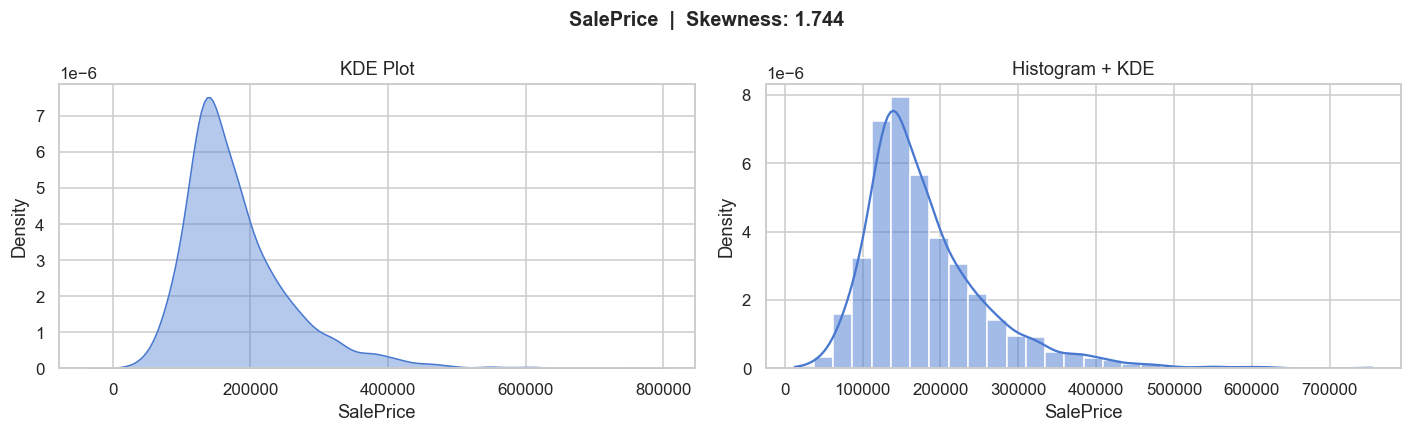

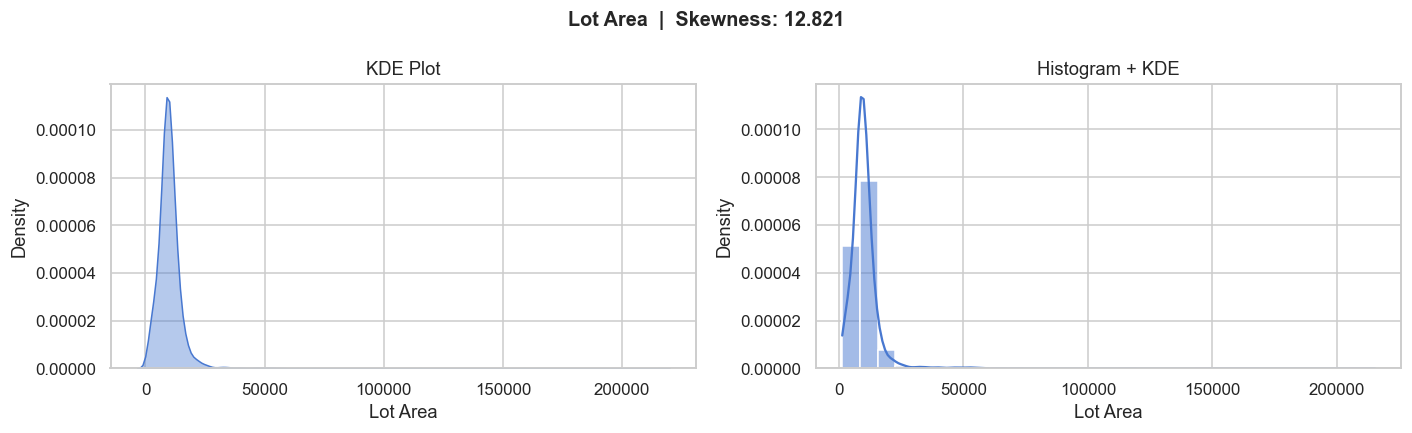

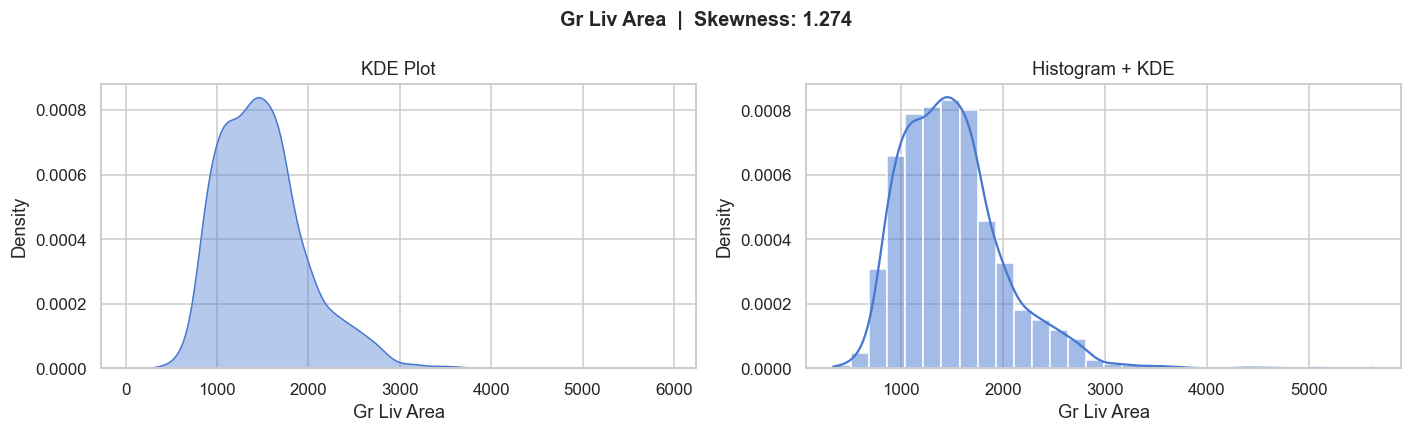

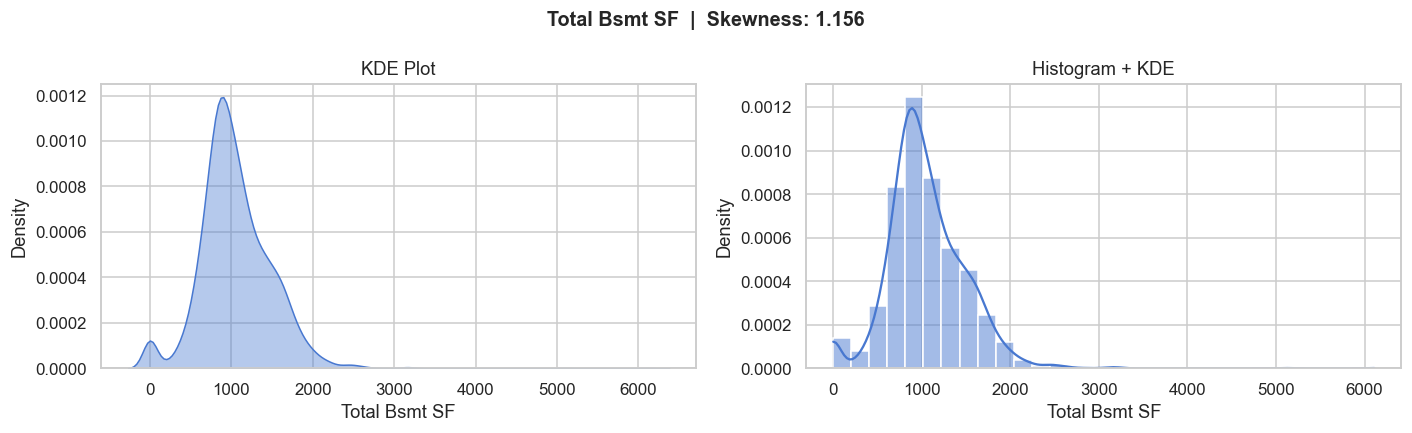

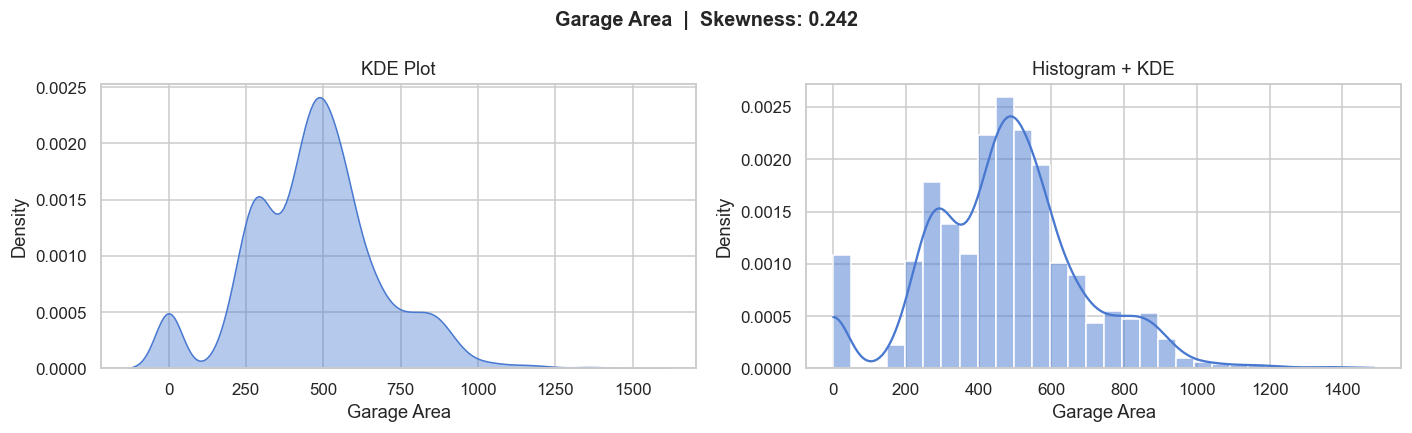

In [5]:
def plot_raw_distribution(df: pd.DataFrame, features: list) -> None:
    """
    Plot KDE and Histogram+KDE side-by-side for each feature.

    Parameters
    ----------
    df       : pd.DataFrame  — source dataframe
    features : list          — list of column names to plot
    """
    for col in features:
        skew_val = df[col].skew()
        fig, axes = plt.subplots(1, 2, figsize=(13, 4))
        fig.suptitle(f"{col}  |  Skewness: {skew_val:.3f}", fontsize=13, fontweight='bold')

        # Left: pure KDE — shows the overall shape of the distribution
        sns.kdeplot(df[col].dropna(), ax=axes[0], fill=True, alpha=0.4)
        axes[0].set_title("KDE Plot")
        axes[0].set_xlabel(col)

        # Right: histogram overlaid with KDE — shows both frequency and shape
        sns.histplot(df[col].dropna(), kde=True, bins=30,
                     stat='density', edgecolor='white', ax=axes[1])
        axes[1].set_title("Histogram + KDE")
        axes[1].set_xlabel(col)

        plt.tight_layout()
        plt.show()


plot_raw_distribution(data, FEATURES)

---
## 4. ⚙️ Apply Transformations

We define a helper function that applies **10 transformations** to any numeric series.  
Here is a quick reference for each:

| Transformation | Formula | Best Used When |
|---|---|---|
| **Log** | `log(x)` or `log1p(x)` | Moderate-to-heavy right skew; all values > 0 |
| **Square Root** | `√x` | Mild right skew; count data |
| **Square** | `x²` | Left-skewed data |
| **Cube** | `x³` | Left-skewed, stronger correction |
| **Reciprocal** | `1/x` | Extreme right skew (use with care) |
| **Exponential** | `eˣ` | Left-skewed data |
| **Box-Cox** | Optimal power λ | Any right-skewed, strictly positive data |
| **Yeo-Johnson** | Generalised Box-Cox | Any skew; handles zero and negative values |
| **Quantile** | Maps to normal/uniform | Non-parametric; works on any distribution |
| **Rank** | `rank()` | Non-parametric; robust to outliers |


In [6]:
def apply_transformations(series: pd.Series) -> dict:
    """
    Apply a comprehensive set of transformations to a numeric series.

    A positive shift is applied automatically when values are ≤ 0 so that
    transformations requiring strictly positive input (log, Box-Cox) still work.

    Parameters
    ----------
    series : pd.Series
        Numeric column to transform.

    Returns
    -------
    dict
        Mapping of transformation name → transformed numpy array or pd.Series.
    """
    s = series.dropna()

    # Shift to strictly positive if necessary (keeps relative distances intact)
    if (s <= 0).any():
        s = s + abs(s.min()) + 1

    results = {}

    # ── Simple algebraic transforms ───────────────────────────
    results['original']   = s
    results['log']        = np.log(s)                          # Natural log
    results['sqrt']       = np.sqrt(s)                         # Square root
    results['square']     = np.power(s, 2)                     # Squared
    results['cube']       = np.power(s, 3)                     # Cubed
    results['reciprocal'] = 1 / s                              # 1/x
    results['exp']        = np.exp(s / s.max())                # Scaled exp to avoid overflow

    # ── Box-Cox: finds the optimal power lambda automatically ─
    # Requires strictly positive values (already enforced above).
    try:
        bc_transformed, _ = boxcox(s)
        results['boxcox'] = bc_transformed
    except Exception:
        results['boxcox'] = np.nan  # Fallback if transform fails

    # ── Yeo-Johnson: generalization of Box-Cox ────────────────
    # Handles zero and negative values — more flexible in practice.
    pt_yj = PowerTransformer(method='yeo-johnson')
    results['yeo_johnson'] = pt_yj.fit_transform(s.values.reshape(-1, 1)).flatten()

    # ── Quantile transform → maps to a normal distribution ───
    # Fully non-parametric; ignores the original scale.
    qt = QuantileTransformer(output_distribution='normal', random_state=42)
    results['quantile'] = qt.fit_transform(s.values.reshape(-1, 1)).flatten()

    # ── Rank transform ────────────────────────────────────────
    # Converts values to their rank order; very robust to outliers.
    results['rank'] = s.rank(method='average')

    return results


print("✅ apply_transformations() defined — 10 transforms ready")

✅ apply_transformations() defined — 10 transforms ready


### 4.1 Build a Summary Table — All Transforms × All Features

In [7]:
summary_records = []

for col in FEATURES:
    transforms = apply_transformations(data[col])

    for t_name, t_data in transforms.items():
        # Skip failed transforms (stored as scalar float NaN)
        if isinstance(t_data, float):
            continue

        stats = compute_diagnostics(pd.Series(t_data))
        summary_records.append({'Feature': col, 'Transformation': t_name, **stats})


summary_df = (
    pd.DataFrame(summary_records)
    .round(3)
    .set_index(['Feature', 'Transformation'])
)

# Preview results for SalePrice
print("=== SalePrice — Statistics Across All Transformations ===")
summary_df.loc['SalePrice']

=== SalePrice — Statistics Across All Transformations ===


,Mean,Median,Skewness,Kurtosis,IQR Outliers,Z-score Outliers
Transformation,,,,,,
original,1.807961e+05,1.600000e+05,1.744,5.119,137,45
log,1.202000e+01,1.198000e+01,-0.015,1.514,60,20
sqrt,4.162600e+02,4.000000e+02,0.885,1.641,93,31
square,3.906692e+10,2.560000e+10,4.220,29.928,241,57
cube,1.025797e+16,4.096000e+15,8.513,114.626,315,44
reciprocal,0.000000e+00,0.000000e+00,7.696,144.068,100,27
exp,1.280000e+00,1.240000e+00,2.552,11.764,166,51
boxcox,1.259000e+01,1.255000e+01,0.002,1.476,59,20
yeo_johnson,0.000000e+00,-9.000000e-02,0.002,1.476,59,20


---
## 5. 📈 Compare Transformations — Visual Dashboard

For each feature we plot the five most practically useful transforms:

- **Original** — baseline
- **Log** — most common remedy for right skew
- **Square Root** — gentler correction
- **Box-Cox** — data-driven optimal power
- **Yeo-Johnson** — like Box-Cox but no positivity constraint

Each column shows:
- **Row 1:** Histogram + KDE
- **Row 2:** KDE with skewness & kurtosis annotated


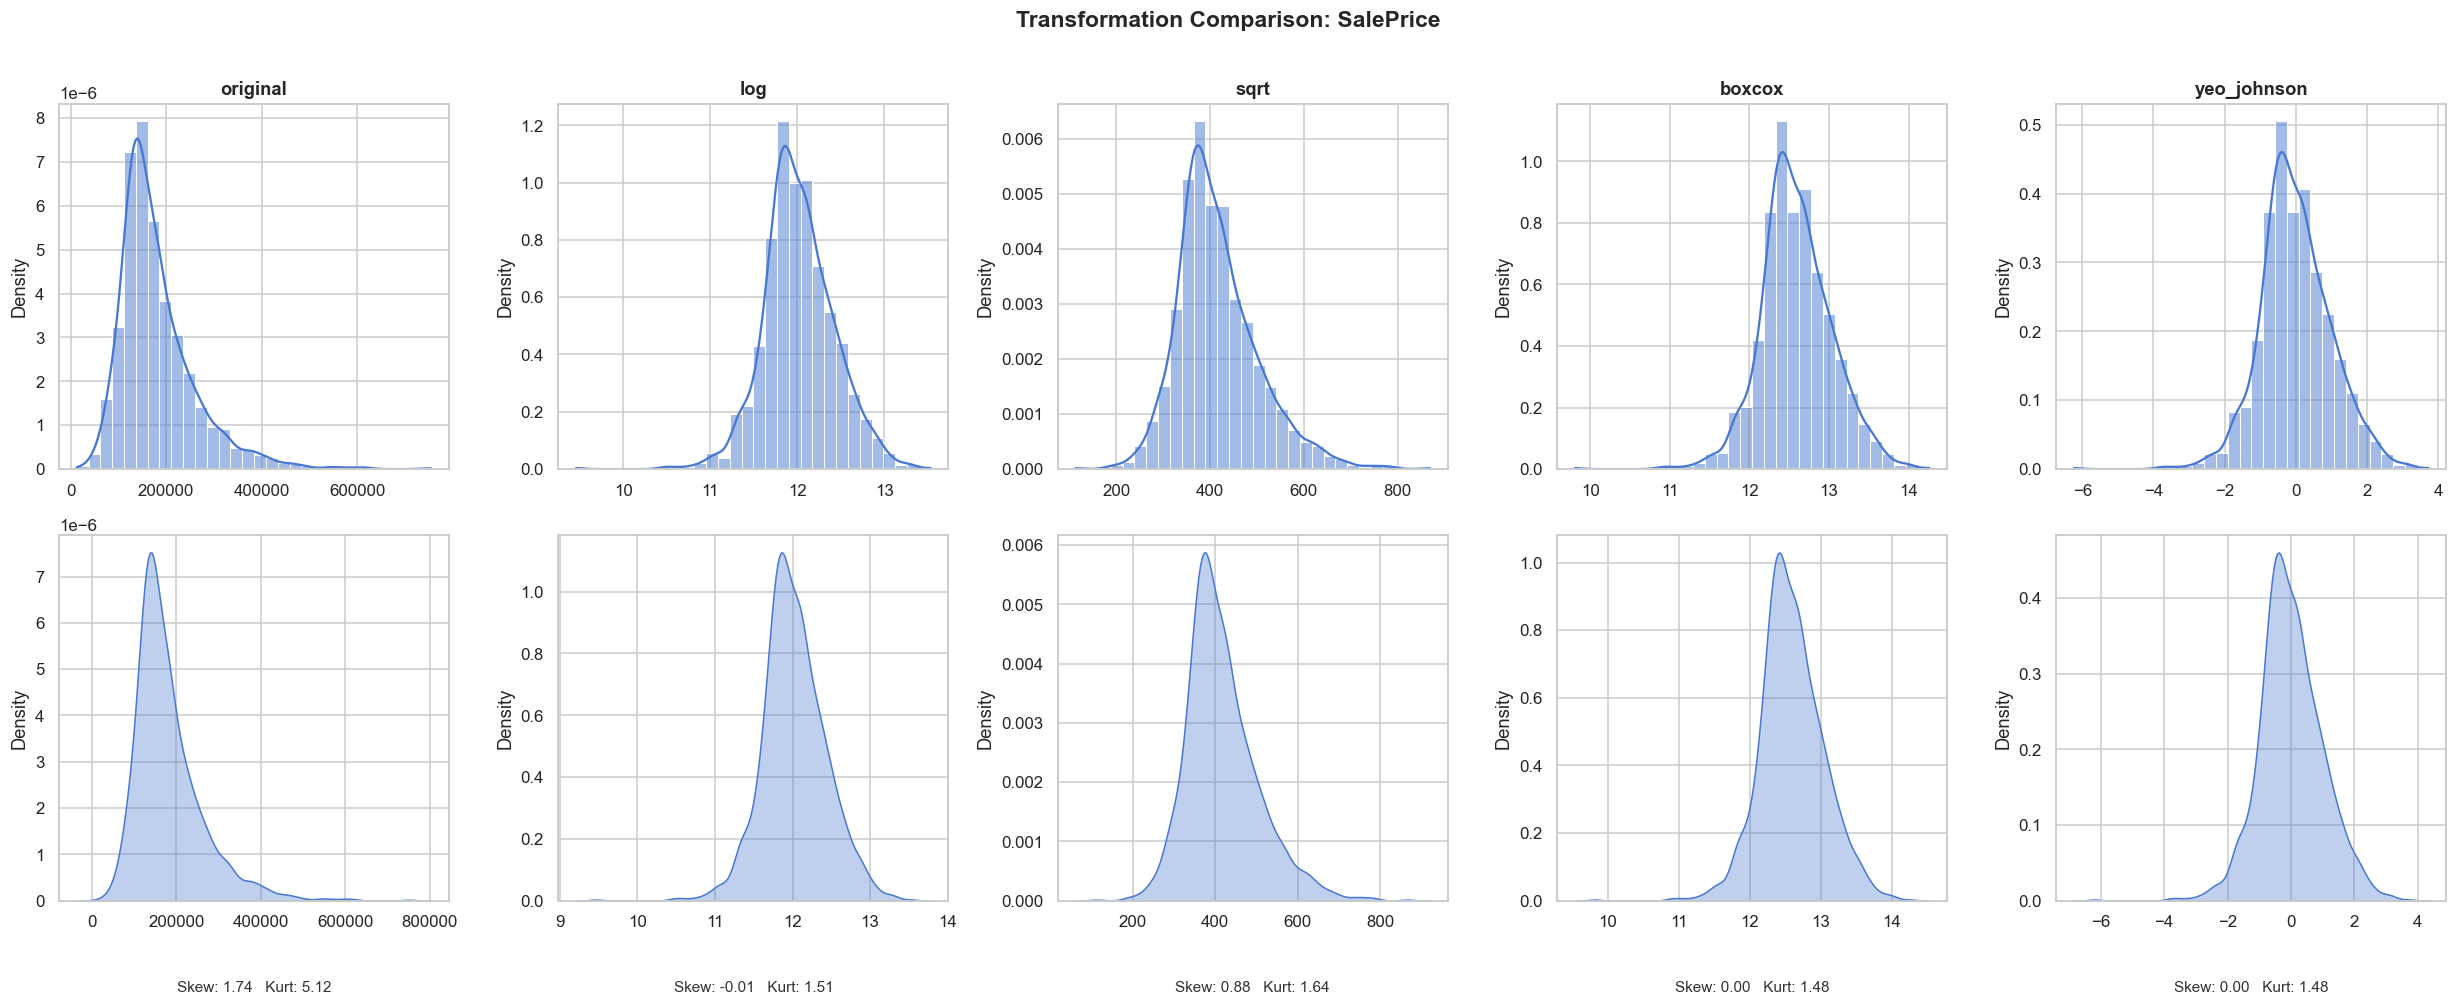

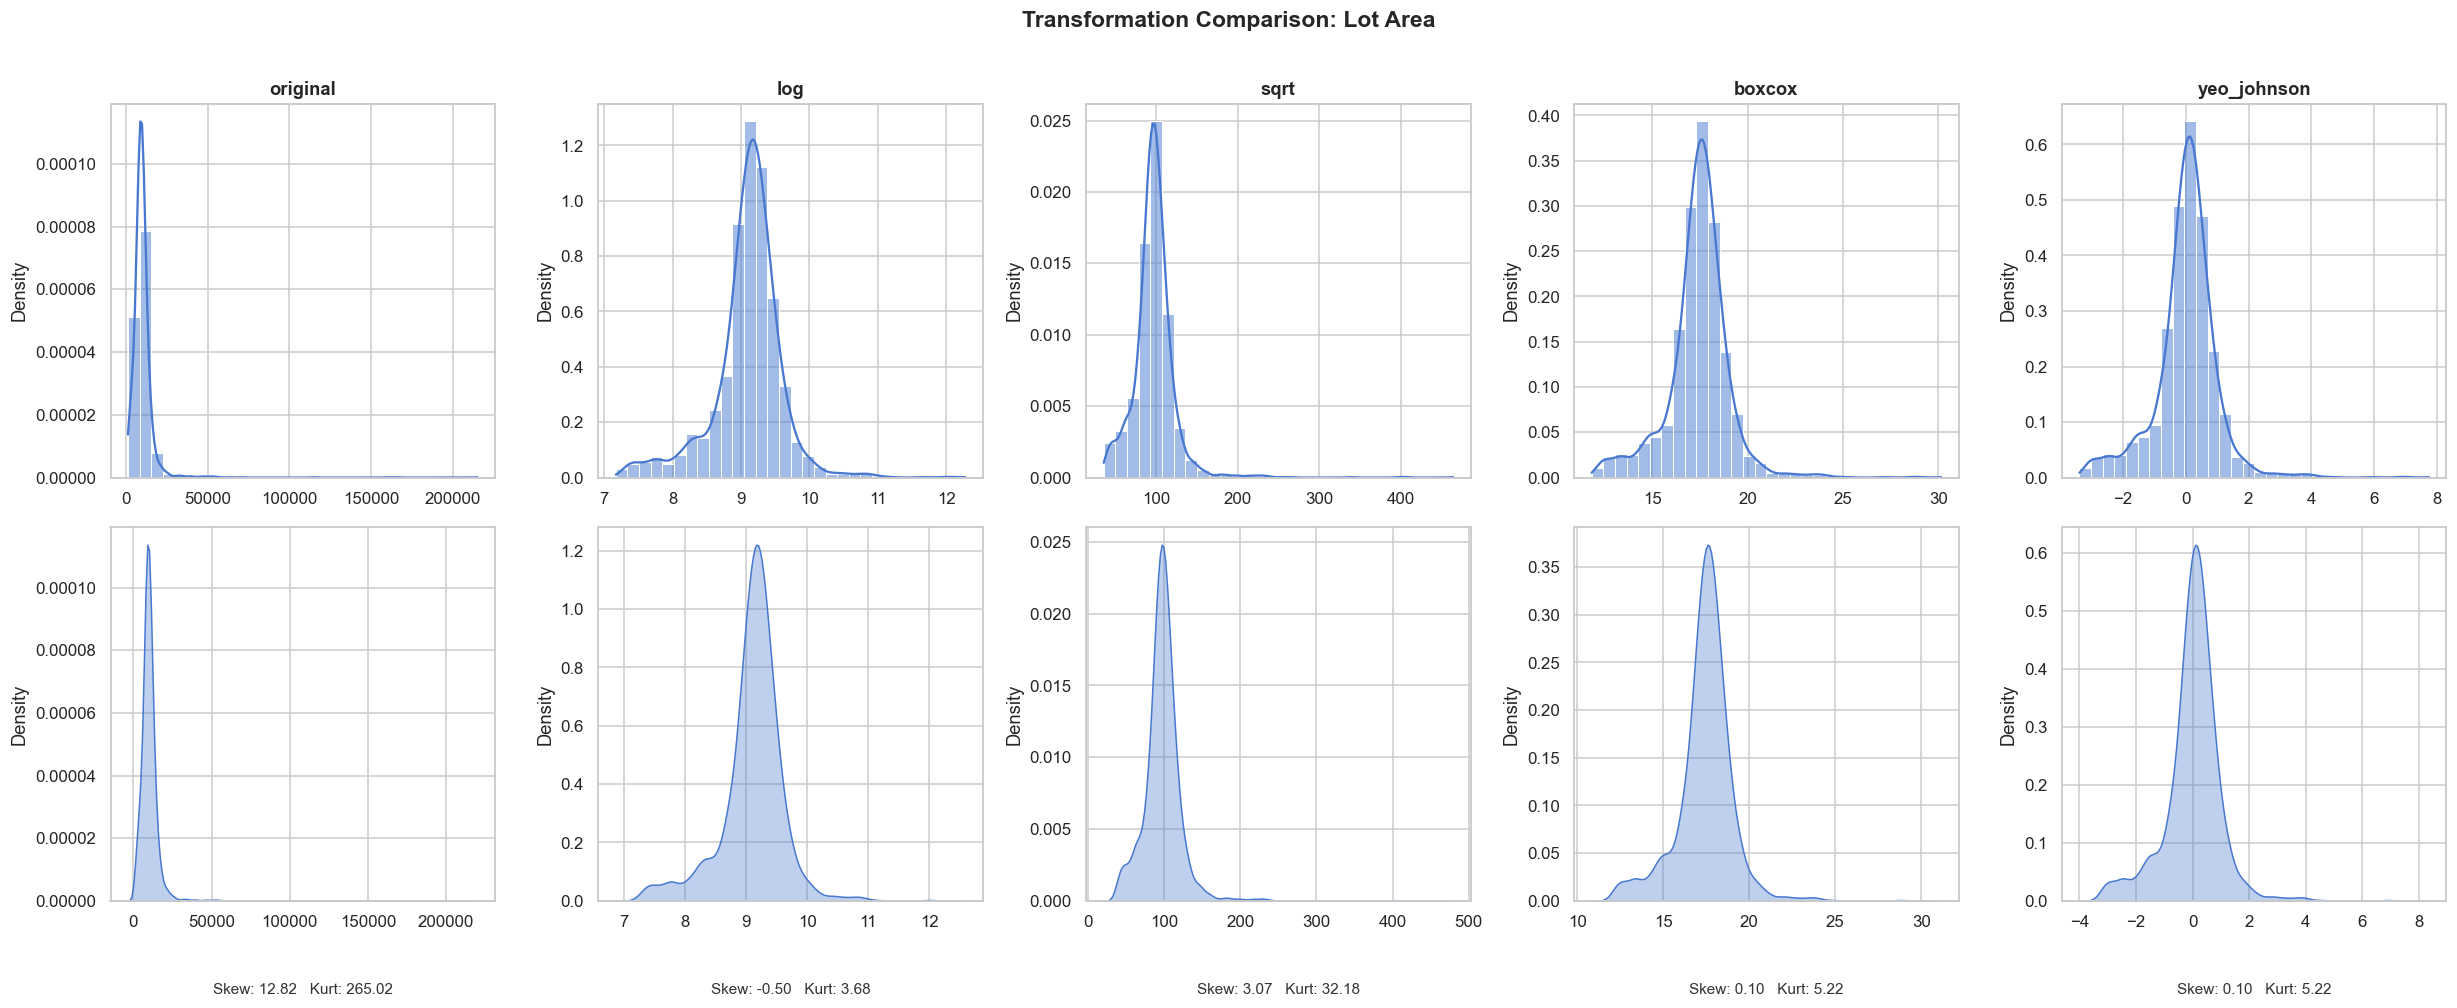

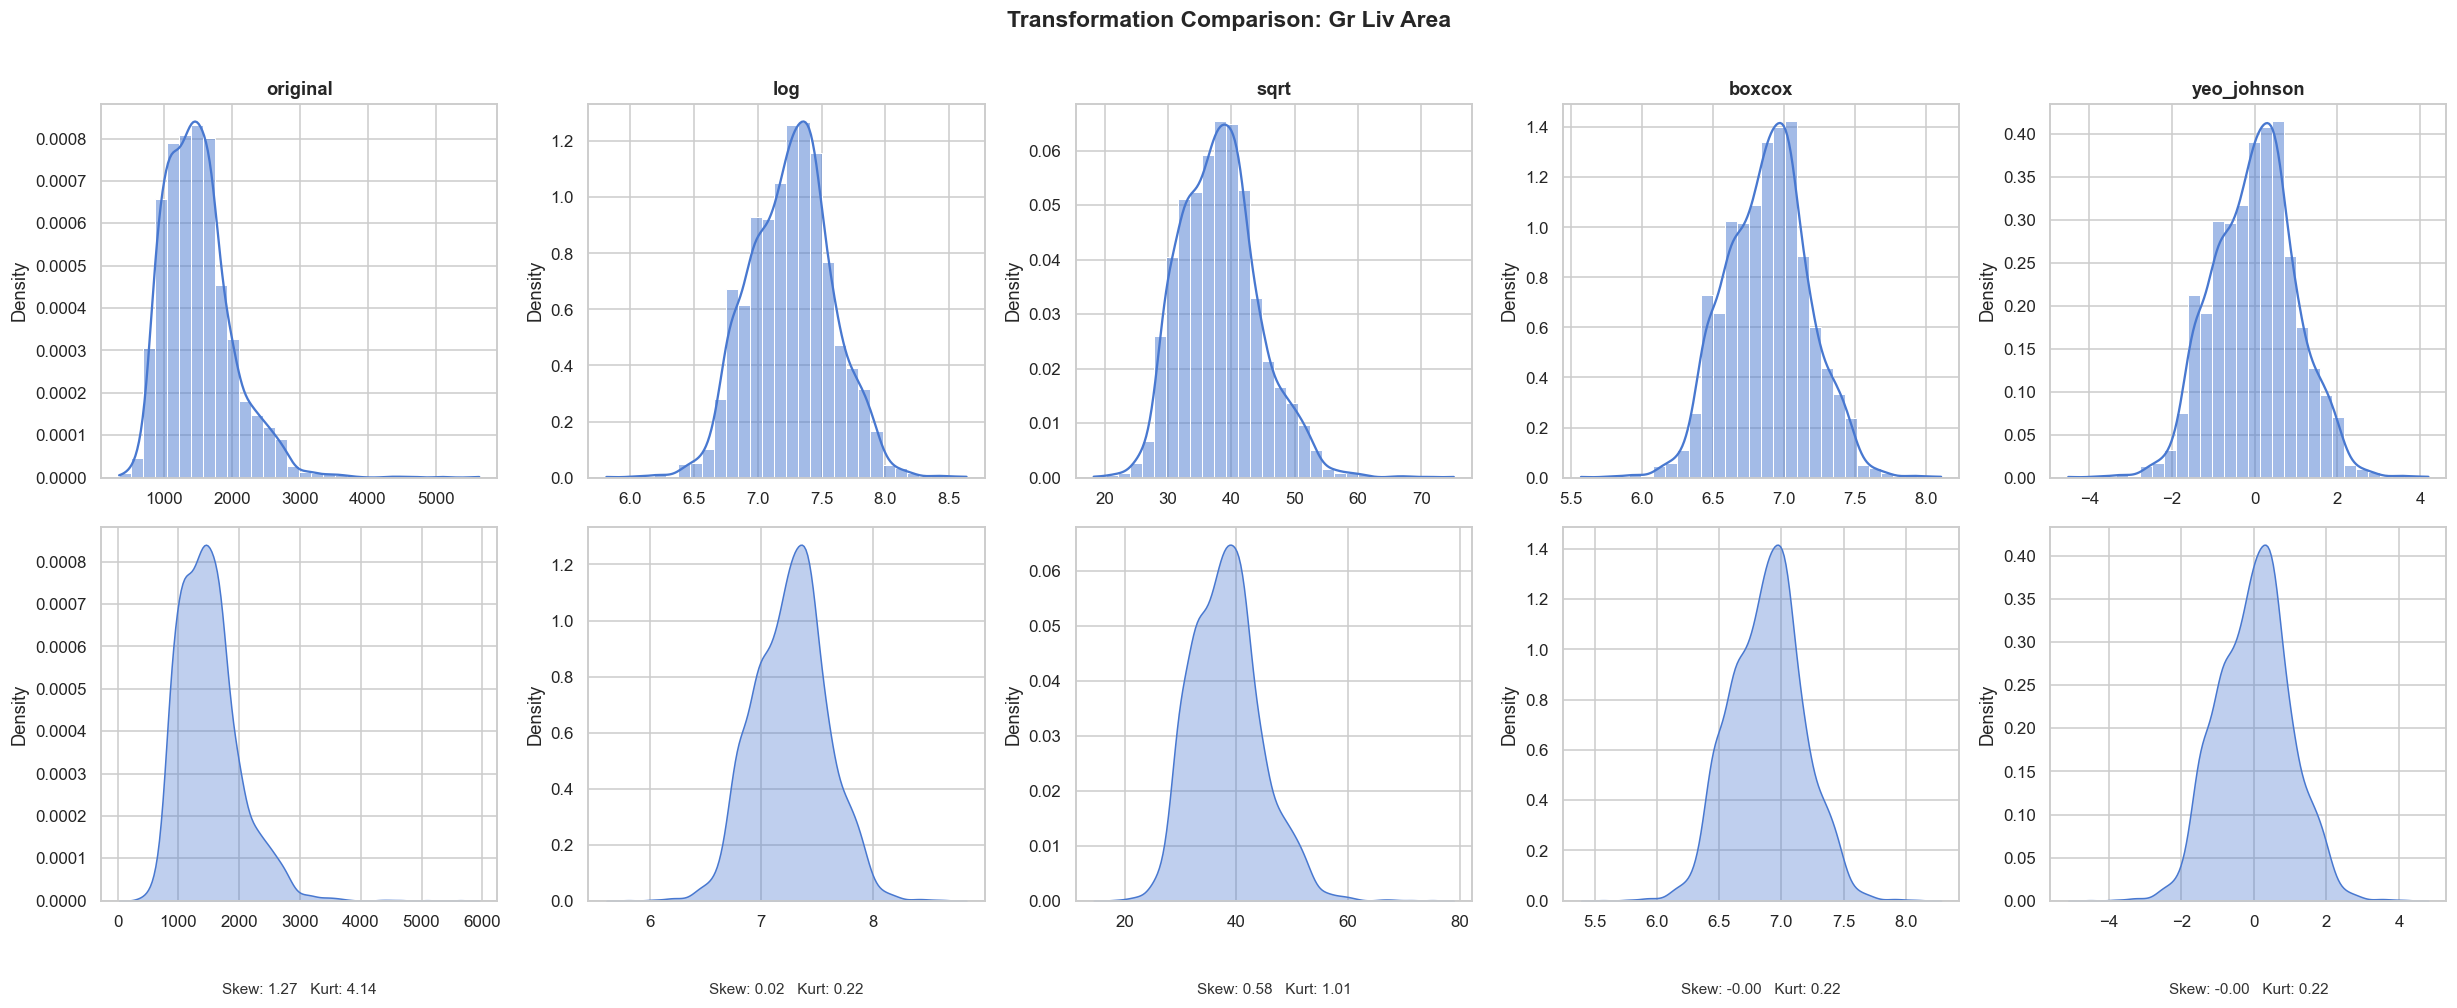

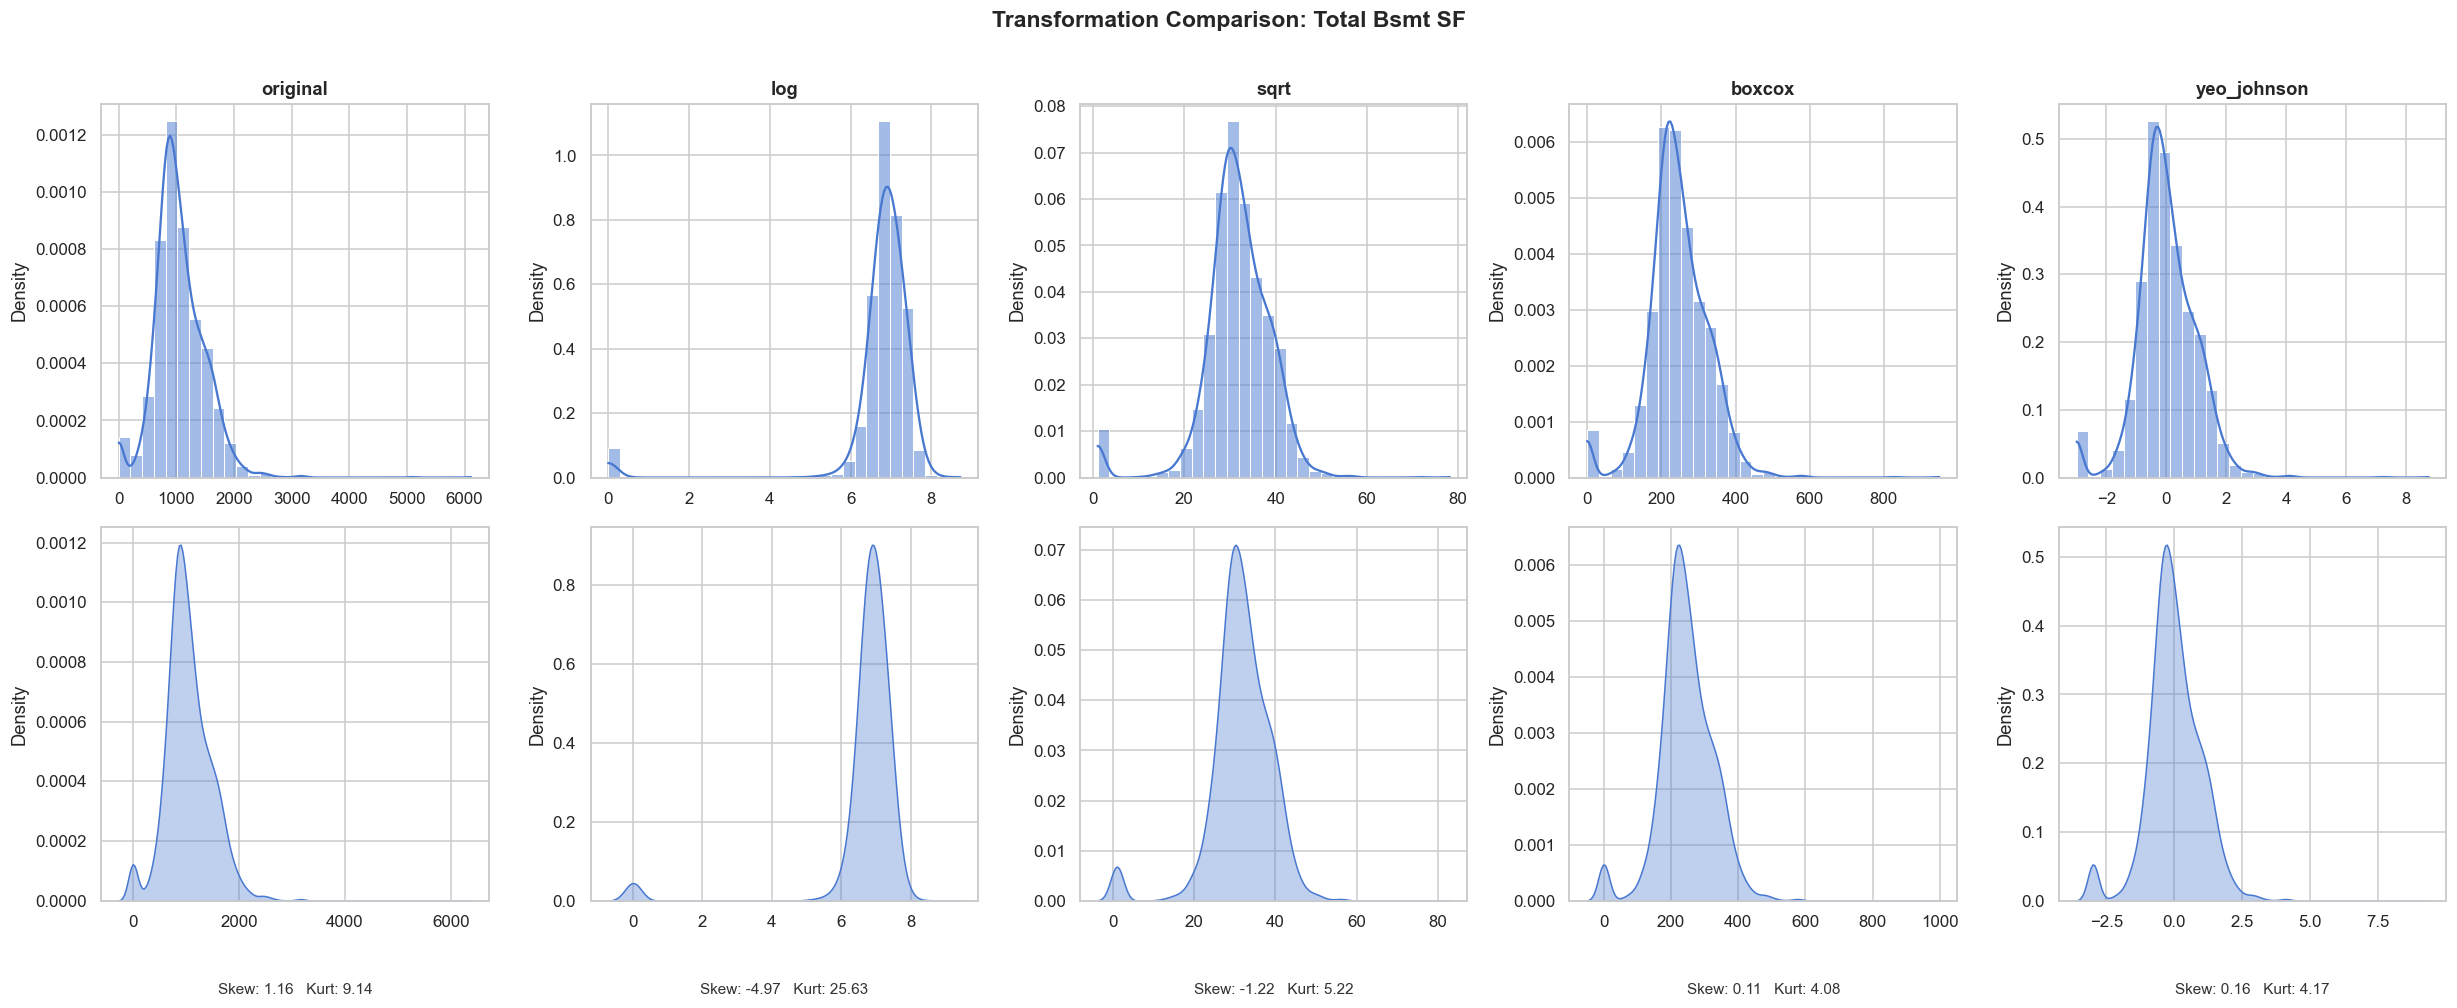

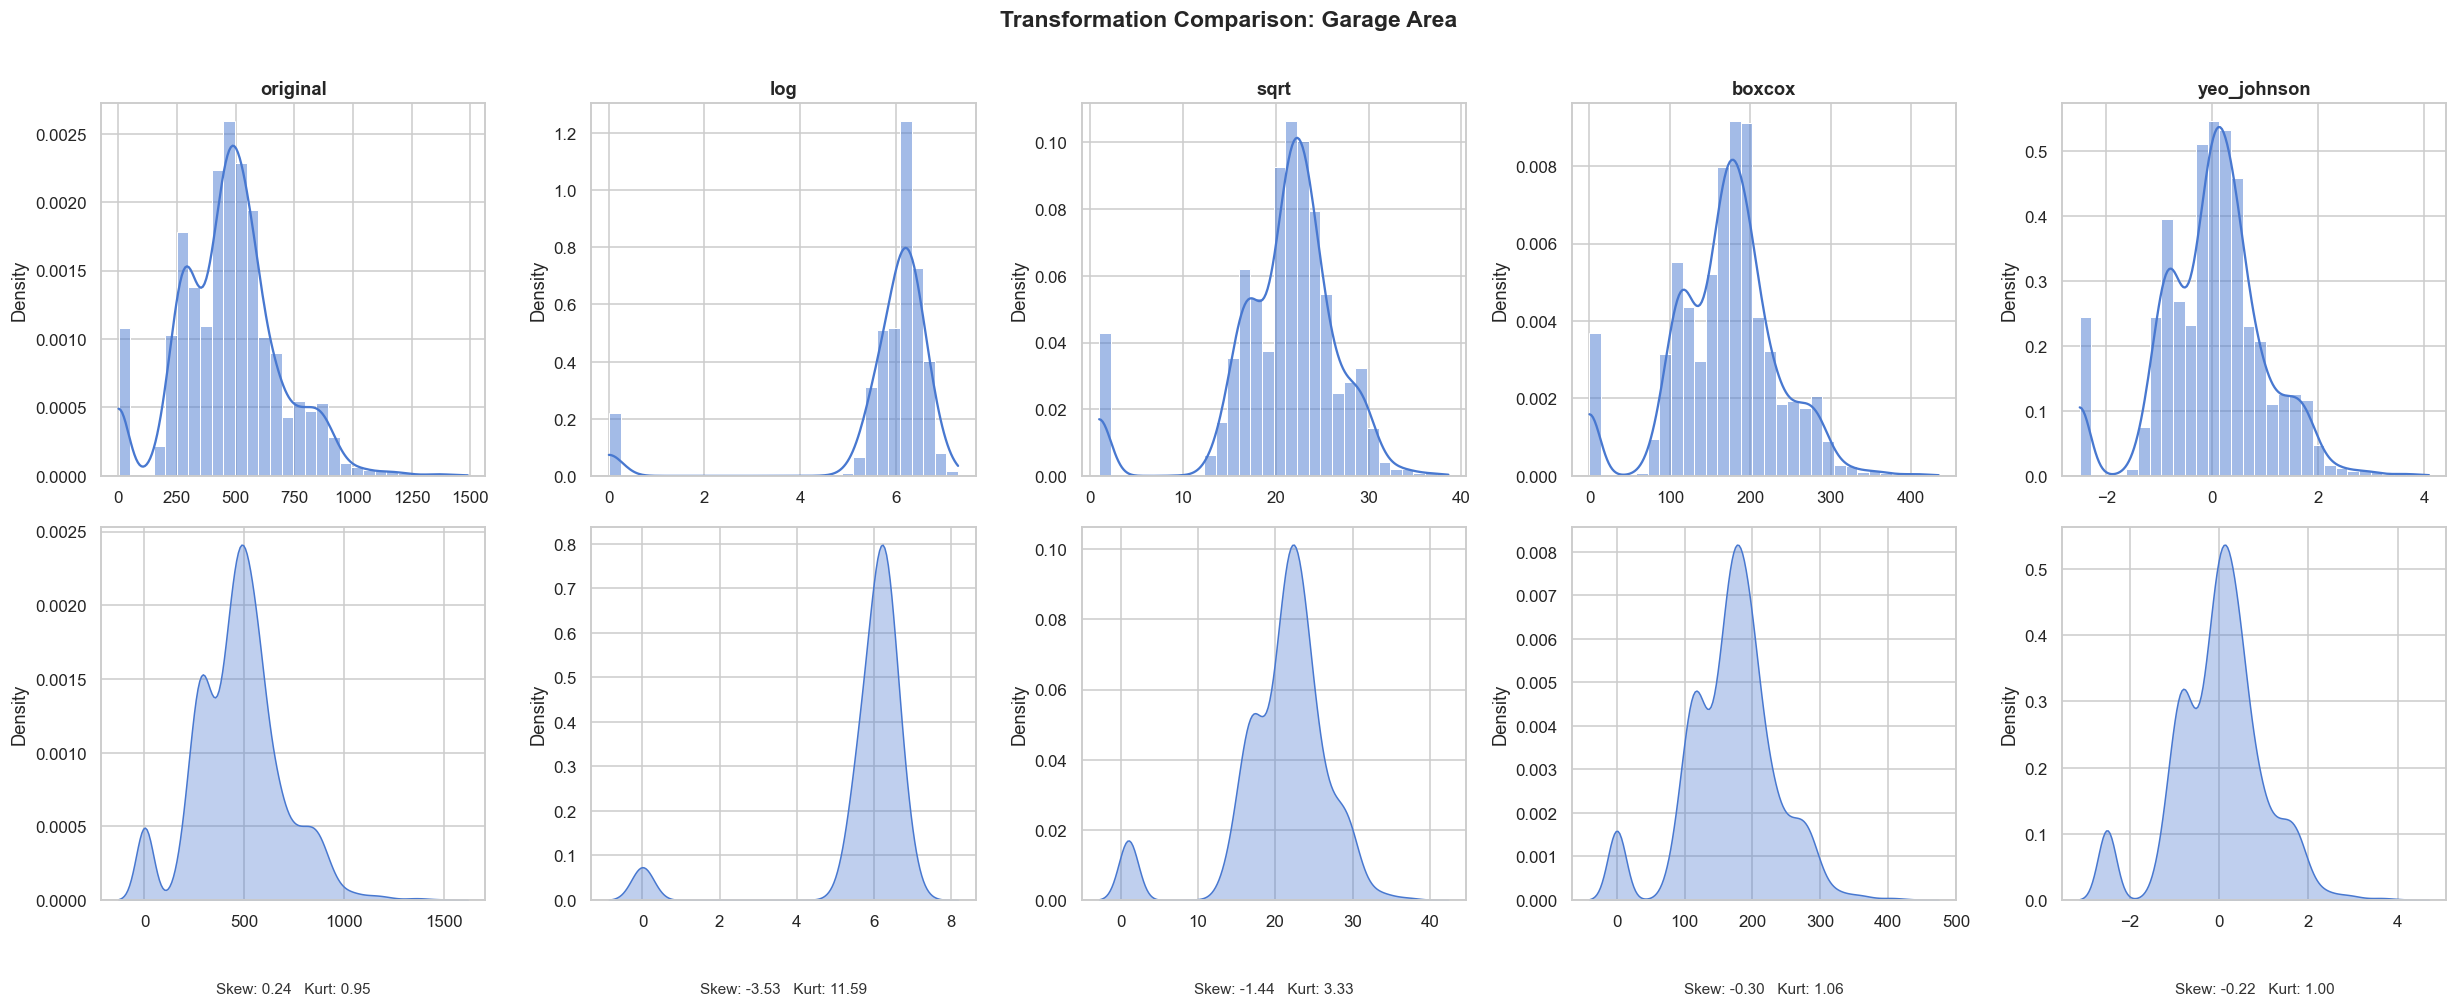

In [8]:
USEFUL_TRANSFORMS = ['original', 'log', 'sqrt', 'boxcox', 'yeo_johnson']

def plot_transformation_dashboard(df: pd.DataFrame, features: list) -> None:
    """
    For each feature, display a 2-row dashboard comparing selected transformations.

    Row 1: Histogram + KDE for each transform
    Row 2: KDE with skewness and kurtosis annotated below

    Parameters
    ----------
    df       : pd.DataFrame  — source dataframe
    features : list          — feature column names to plot
    """
    for col in features:
        transforms = apply_transformations(df[col])

        # Keep only the transforms we care about, skipping any that failed
        valid = {
            k: v for k, v in transforms.items()
            if k in USEFUL_TRANSFORMS and not isinstance(v, float)
        }

        n = len(valid)
        fig, axes = plt.subplots(2, n, figsize=(4.5 * n, 9))
        fig.suptitle(
            f"Transformation Comparison: {col}",
            fontsize=15, fontweight='bold', y=1.01
        )

        for i, (t_name, t_values) in enumerate(valid.items()):
            values = pd.Series(t_values).dropna()
            skew_val = values.skew()
            kurt_val = values.kurt()

            # ── Row 1: Histogram + KDE ─────────────────────────
            sns.histplot(values, kde=True, bins=30, stat='density',
                         edgecolor='white', ax=axes[0, i])
            axes[0, i].set_title(t_name, fontsize=12, fontweight='bold')
            axes[0, i].set_xlabel("")

            # ── Row 2: KDE with stats annotation ──────────────
            sns.kdeplot(values, ax=axes[1, i], fill=True, alpha=0.35)
            axes[1, i].set_xlabel("")

            # Annotate skewness and kurtosis below each KDE plot
            axes[1, i].text(
                0.5, -0.22,
                f"Skew: {skew_val:.2f}   Kurt: {kurt_val:.2f}",
                ha='center', va='top',
                transform=axes[1, i].transAxes,
                fontsize=10, color='#333333'
            )

        plt.tight_layout()
        plt.show()


plot_transformation_dashboard(data, FEATURES)

---
## 6. 🧭 Choosing the Right Transformation

Use this decision guide as a starting point:

```
Is the data right-skewed?
├── Mild skew (0.5–1.0)  → Try Square Root
├── Moderate skew (1–2)  → Try Log or Box-Cox
└── Severe skew (>2)     → Try Box-Cox or Yeo-Johnson

Does the data contain zeros or negatives?
├── Yes → Use Yeo-Johnson (or log1p if only zeros)
└── No  → Box-Cox is available

Do you need a non-parametric approach?
└── Yes → Quantile Transform or Rank Transform
```

### Validation checklist after transformation:
1. **Skewness closer to 0?** (target: |skew| < 0.5)
2. **Kurtosis reduced?** (target: < 3)
3. **Fewer IQR or Z-score outliers?**
4. **Does the KDE now resemble a bell curve?**

If yes to most of the above — the transformation is working. ✅


In [9]:
# ─────────────────────────────────────────────────────────────
# Final summary: rank transformations by absolute skewness for each feature.
# Lower |skewness| = distribution is closer to normal = better for most models.
# ─────────────────────────────────────────────────────────────

ranking = (
    summary_df
    .reset_index()
    .assign(AbsSkewness=lambda df: df['Skewness'].abs())
    [['Feature', 'Transformation', 'Skewness', 'AbsSkewness', 'IQR Outliers']]
    .sort_values(['Feature', 'AbsSkewness'])
    .groupby('Feature')
    .head(3)  # Top 3 transforms per feature
    .reset_index(drop=True)
)

print("=== Top 3 Transformations per Feature (by lowest |skewness|) ===")
ranking

=== Top 3 Transformations per Feature (by lowest |skewness|) ===


,Feature,Transformation,Skewness,AbsSkewness,IQR Outliers
0,Garage Area,rank,0.001,0.001,0
1,Garage Area,yeo_johnson,-0.224,0.224,191
2,Garage Area,original,0.242,0.242,42
3,Gr Liv Area,boxcox,-0.000,0.000,23
4,Gr Liv Area,yeo_johnson,-0.000,0.000,23
5,Gr Liv Area,quantile,0.000,0.000,21
6,Lot Area,rank,0.000,0.000,0
7,Lot Area,quantile,0.004,0.004,21
8,Lot Area,yeo_johnson,0.101,0.101,250
9,SalePrice,rank,0.000,0.000,0


---

## 🔁 What Comes Next?

After choosing the right transformation for each feature, the typical ML pipeline continues:

1. **Handle missing values** — impute before transforming
2. **Apply transformation** ← *you are here*
3. **Feature scaling** — MinMax, StandardScaler, RobustScaler, etc.
4. **Encode categoricals** — one-hot, ordinal, target encoding
5. **Model training & evaluation**

---